# Noise with GHZ state

### What is $n$-Qubit GHZ State ?

An \( n \)-qubit GHZ (Greenberger-Horne-Zeilinger) state is a type of entangled quantum state that generalizes the concept of Bell states to multiple qubits. It is defined as:

$$ |\text{GHZ}_n\rangle = \frac{1}{\sqrt{2}} \left( |0\rangle^{\otimes n} + |1\rangle^{\otimes n} \right) $$

This state represents an equal superposition of all qubits being in the ∣0⟩ state and all qubits being in the  ∣1⟩ state simultaneously. 

**Example:** 


For example, the 3-qubit GHZ state is:
$$ |\text{GHZ}_3\rangle = \frac{1}{\sqrt{2}} \left( |000\rangle + |111\rangle \right) $$
For a 10-qubit GHZ state,  the state vector would be:

$$ |\text{GHZ}_{10}\rangle = \frac{1}{\sqrt{2}} \left( |0000000000\rangle + |1111111111\rangle \right) $$


### Create  $|\text{GHZ}_3\rangle = \frac{1}{\sqrt{2}} \left( |000\rangle + |111\rangle \right)$ State

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import cirq

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range (2**num_qubits)]

plt.rcParams.update({'font.size': 8})

**Function for creating n-Qubit GHZ state :**

In [2]:
def create_n_qubit_ghz_state(n):
    qubits = cirq.NamedQubit.range(n, prefix='q')
    circuit = cirq.Circuit()
    circuit.append(cirq.H(qubits[0]))
    
    for i in range(n-1):
        circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
    
    circuit.append(cirq.measure(qubits))        # Use only when need to simulate
    
    return circuit

### Question 1: Run and simulate the circuit with `No noise`. 

q0: ───H───@───────M───
           │       │
q1: ───────X───@───M───
               │   │
q2: ───────────X───M───


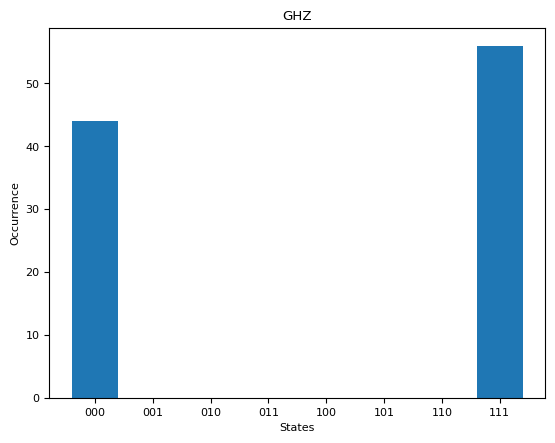

In [3]:
# Create circuit
circuit = create_n_qubit_ghz_state(3)
print(circuit)


#print(cirq.dirac_notation(cirq.final_state_vector(circuit))) # Use when there is no measurement and simulate


# Simulate
sim = cirq.Simulator()

result = sim.run(circuit, repetitions=100)

# Plot
hist = cirq.plot_state_histogram(result, plt.subplot(), title='GHZ', xlabel='States', ylabel='Occurrence', tick_label=binary_labels(3))

plt.show()

### Question 1: Run and simulate with 25% chance of `Depolarization` throughout the whole circuit.

**Depolarization :**

- Depolarization is a type of noise that causes a quantum state to lose its original information and become a completely mixed state with some probability.

**Effect :**

- It uniformly randomizes the state of the qubit, effectively "blurring" its state with equal probability of being in any of the possible states.

**Impact :**

- Depolarization affects all parts of the qubit's state equally and is often used to model errors that have no specific directional bias.


q0: ───H───@───────M───
           │       │
q1: ───────X───@───M───
               │   │
q2: ───────────X───M───


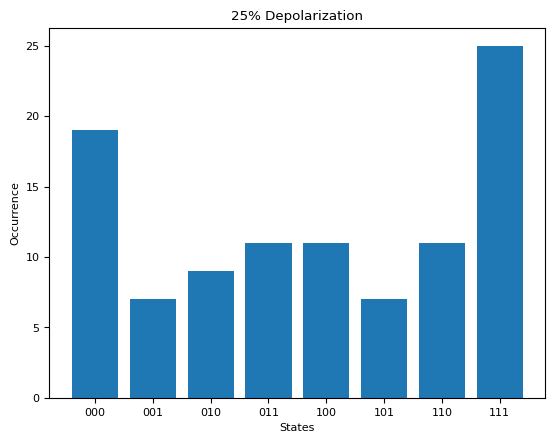

In [4]:
# Create circuit
circuit = create_n_qubit_ghz_state(3)
print(circuit)


# Add Noise Model 

noise = cirq.depolarize(0.25)


# Simulate
sim = cirq.Simulator()

result = sim.run(circuit.with_noise(noise), repetitions=100)

# Plot
hist = cirq.plot_state_histogram(result, plt.subplot(), title='25% Depolarization', xlabel='States', ylabel='Occurrence', tick_label=binary_labels(3))

plt.show()

### Question 2: Run and simulate with 25% chance of `Phase Flipping` throughout the whole circuit.

**Phase Flipping :**

- Phase flipping is a type of error that inverts the phase of a quantum state, flipping the sign of the phase component in the state vector.

**Effect**

- A phase flip changes the sign of the relative phase between the states $|0\rangle$ and $|1\rangle$. It affects superposition states like $|+\rangle$ and $|-\rangle$.

**Impact :**

- Phase flips do not change the probabilities of measuring $|0\rangle$ or $|1\rangle$, but they can disrupt quantum algorithms that rely on precise phase relationships, like interference-based algorithms.


q0: ───H───@───────M───
           │       │
q1: ───────X───@───M───
               │   │
q2: ───────────X───M───


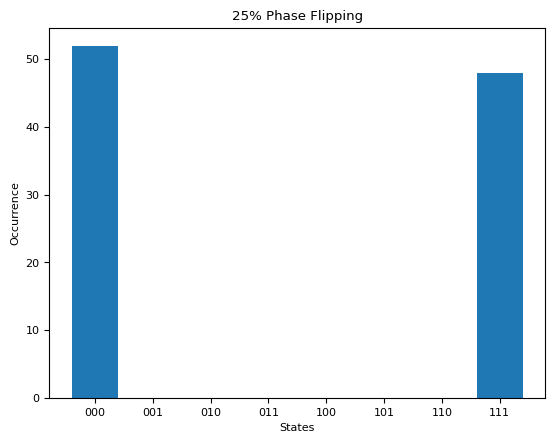

In [5]:
# Create circuit
circuit = create_n_qubit_ghz_state(3)
print(circuit)


# Add Noise Model 

noise = cirq.phase_flip(0.25)


# Simulate
sim = cirq.Simulator()

result = sim.run(circuit.with_noise(noise), repetitions=100)

# Plot
hist = cirq.plot_state_histogram(result, plt.subplot(), title='25% Phase Flipping', xlabel='States', ylabel='Occurrence', tick_label=binary_labels(3))

plt.show()

### Question 3: Run and simulate with 25% chance of `Amplitude Damping` throughout the whole circuit.

**Amplitude Damping :**

- Amplitude damping describes the process where a qubit loses energy, typically due to interaction with its environment, causing it to relax to the $|0\rangle$ state.

**Effect :**

- This type of noise models phenomena like spontaneous emission, where excited states lose energy and decay to lower energy states.

**Impact :**

- Amplitude damping reduces the population of excited states, which can lead to loss of information stored in qubits, particularly affecting quantum memory and long-running computations.


q0: ───H───@───────M───
           │       │
q1: ───────X───@───M───
               │   │
q2: ───────────X───M───


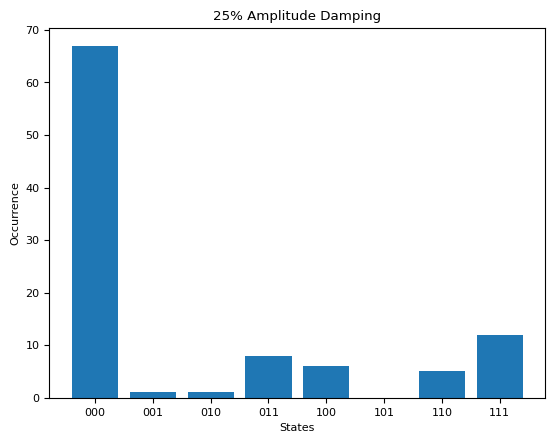

In [6]:
# Create circuit
circuit = create_n_qubit_ghz_state(3)
print(circuit)


# Add Noise Model 

noise = cirq.amplitude_damp(0.25)


# Simulate
sim = cirq.Simulator()

result = sim.run(circuit.with_noise(noise), repetitions=100)

# Plot
hist = cirq.plot_state_histogram(result, plt.subplot(), title='25% Amplitude Damping', xlabel='States', ylabel='Occurrence', tick_label=binary_labels(3))

plt.show()

### Conclusion

- **Depolarization** randomizes the state entirely, affecting all components of a qubit’s state.

- **Phase Flipping** changes the relative phase, impacting interference patterns critical for certain quantum operations.No change in Entangled states.

- **Amplitude Damping** models energy loss, pushing the system toward lower energy states (0), which can degrade information stored in excited states.
